# quantization recovery and speculative decoding, from scratch

two research pillars, both built on top of a hand-written quantization harness (round-to-nearest, gptq, smoothquant - no bitsandbytes, no autogptq).

pillar 1: post-training quantization at 4 bits fails a quality gate. can quantization-aware training or distillation recover the lost quality, and which recovers more per training step?

pillar 2: speculative decoding is provably lossless under an exact acceptance criterion. what happens to speed and output fidelity as that criterion is relaxed, and does the draft model's own quantization level change how often it gets accepted?

runs on kaggle t4x2, both gpus used concurrently for the qat/distillation training. no code comments anywhere - explanation lives in the markdown cells. style: 2-space indent, no spaces around commas or equals signs, no capital letters in code except where python or a library requires them (true/false/none, exact huggingface model names, external library class names like adam or automodelforcausallm).

In [1]:
!pip install -q transformers accelerate datasets

In [2]:
import copy
import gc
import json
import math
import threading
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as f

%matplotlib inline

## real calibration and eval text

wikitext-2 pulled live from the hub. if the download hiccups, a small built-in fallback keeps the rest of the notebook runnable.

In [3]:
def load_wikitext():
  try:
    from datasets import load_dataset
    train = load_dataset('wikitext', 'wikitext-2-raw-v1', split='train')
    test = load_dataset('wikitext', 'wikitext-2-raw-v1', split='test')
    train_text = [t for t in train['text'] if len(t.strip())>200]
    test_text = [t for t in test['text'] if len(t.strip())>200]
    return train_text, test_text
  except Exception as e:
    print('wikitext download failed, using fallback text:', e)
    fallback = [
      'the history of computing spans several centuries, beginning with mechanical calculators and evolving through electromechanical devices before the invention of the electronic digital computer in the mid twentieth century.',
      'quarterly revenue grew across every region, led by strong demand in the enterprise segment and continued expansion in emerging markets throughout the fiscal year.',
      'researchers published a new study examining the long-term effects of the treatment on patient outcomes across several clinical trial sites.',
      'the city council approved funding for a new public transit line connecting the two districts after years of community advocacy and planning.',
      'engineers are testing a new battery chemistry that could extend range by up to thirty percent while reducing overall production costs.',
    ]*40
    return fallback, fallback

wikitext_train, wikitext_test = load_wikitext()
print('train passages:', len(wikitext_train), 'test passages:', len(wikitext_test))

README.md: 0.00B [00:00, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

train passages: 14313 test passages: 1723


## harness core: build records, calibration, rtn, gptq, smoothquant

same math validated on real hardware in earlier runs - the gptq hessian is kept on cpu (avoids the oom from keeping every layer's hessian on gpu at once), the cholesky inversion retries with escalating damping when the hessian is rank-deficient, and smoothquant's scale is moved onto the right device before use.

In [4]:
class quality_metrics:

  def __init__(self):
    self.perplexity = None
    self.downstream_accuracy = None
    self.perplexity_delta_pct = None
    self.downstream_delta_pct = None


class perf_metrics:

  def __init__(self):
    self.tokens_per_sec = None
    self.ttft_ms = None
    self.peak_memory_gb = None
    self.weight_memory_gb = None


class build_record:

  def __init__(self, build_id, model_name, technique, bits, group_size, hardware_tag, workload_tag):
    self.build_id = build_id
    self.model_name = model_name
    self.technique = technique
    self.bits = bits
    self.group_size = group_size
    self.hardware_tag = hardware_tag
    self.workload_tag = workload_tag
    self.quality = quality_metrics()
    self.perf = perf_metrics()
    self.passed_quality_gate = None
    self.quality_gate_reason = ''
    self.created_at = time.time()

  def to_dict(self):
    return dict(
      build_id=self.build_id, model_name=self.model_name, technique=self.technique,
      bits=self.bits, group_size=self.group_size, hardware_tag=self.hardware_tag,
      workload_tag=self.workload_tag, passed_quality_gate=self.passed_quality_gate,
      quality_gate_reason=self.quality_gate_reason,
      perplexity=self.quality.perplexity, downstream_accuracy=self.quality.downstream_accuracy,
      perplexity_delta_pct=self.quality.perplexity_delta_pct, downstream_delta_pct=self.quality.downstream_delta_pct,
      tokens_per_sec=self.perf.tokens_per_sec, ttft_ms=self.perf.ttft_ms,
      peak_memory_gb=self.perf.peak_memory_gb, weight_memory_gb=self.perf.weight_memory_gb,
    )


class build_matrix:

  def __init__(self):
    self.records = []

  def add(self, record):
    self.records.append(record)

  def apply_quality_gate(self, record, max_ppl_delta_pct=5.0, max_downstream_delta_pct=2.0):
    reasons = []
    ok = True
    if record.quality.perplexity_delta_pct is not None and record.quality.perplexity_delta_pct>max_ppl_delta_pct:
      ok = False
      reasons.append(f'ppl delta {record.quality.perplexity_delta_pct:.2f}% > {max_ppl_delta_pct}%')
    if record.quality.downstream_delta_pct is not None and record.quality.downstream_delta_pct>max_downstream_delta_pct:
      ok = False
      reasons.append(f'downstream delta {record.quality.downstream_delta_pct:.2f}% > {max_downstream_delta_pct}%')
    record.passed_quality_gate = ok
    record.quality_gate_reason = '; '.join(reasons) if reasons else 'passed'
    return ok

  def summary_table(self):
    rows = []
    header = f"{'build_id':<24}{'technique':<20}{'hw':<8}{'tok/s':>9}{'mem_gb':>9}{'ppl_delta%':>12}{'gate':>7}"
    rows.append(header)
    rows.append('-'*len(header))
    for r in self.records:
      tok_s = f'{r.perf.tokens_per_sec:.1f}' if r.perf.tokens_per_sec else '-'
      mem = f'{r.perf.peak_memory_gb:.2f}' if r.perf.peak_memory_gb else '-'
      ppl_d = f'{r.quality.perplexity_delta_pct:.2f}' if r.quality.perplexity_delta_pct is not None else '-'
      gate = 'pass' if r.passed_quality_gate else ('fail' if r.passed_quality_gate is False else '-')
      rows.append(f'{r.build_id:<24}{r.technique:<20}{r.hardware_tag:<8}{tok_s:>9}{mem:>9}{ppl_d:>12}{gate:>7}')
    return '\n'.join(rows)

In [5]:
class activation_stats:

  def __init__(self):
    self.abs_max = None
    self.sum_xtx = None
    self.n_rows = 0

  def update(self, x_flat):
    x_flat = x_flat.detach().float().cpu()
    batch_max = x_flat.abs().amax(dim=0)
    if self.abs_max is None:
      self.abs_max = batch_max.clone()
    else:
      self.abs_max = torch.maximum(self.abs_max, batch_max)
    xtx = x_flat.T@x_flat
    if self.sum_xtx is None:
      self.sum_xtx = xtx.clone()
    else:
      self.sum_xtx += xtx
    self.n_rows += x_flat.shape[0]

  def hessian(self, damping=0.01):
    h = 2.0*self.sum_xtx/max(self.n_rows, 1)
    mean_diag = torch.diag(h).mean()
    damp = damping*mean_diag
    h = h+damp*torch.eye(h.shape[0], device=h.device, dtype=h.dtype)
    return h


def collect_calibration_stats(model, tokenizer, calib_texts, device='cpu', max_length=512, target_module_types=(nn.Linear,)):
  stats = {}
  handles = []

  def make_hook(name):
    def hook(module, inputs, output):
      x = inputs[0].detach()
      x_flat = x.reshape(-1, x.shape[-1]).to(torch.float32)
      if name not in stats:
        stats[name] = activation_stats()
      stats[name].update(x_flat)
    return hook

  for name, module in model.named_modules():
    if isinstance(module, target_module_types):
      handles.append(module.register_forward_hook(make_hook(name)))

  model.eval()
  with torch.no_grad():
    for text in calib_texts:
      enc = tokenizer(text, return_tensors='pt', truncation=True, max_length=max_length).to(device)
      model(**enc)

  for h in handles:
    h.remove()

  return stats

In [6]:
def quant_params_per_group(w_group, bits, symmetric=True):
  qmax = 2**(bits-1)-1
  qmin = -2**(bits-1)
  if symmetric:
    max_abs = w_group.abs().amax(dim=-1, keepdim=True).clamp(min=1e-8)
    scale = max_abs/qmax
    zero_point = torch.zeros_like(scale)
  else:
    qmax_u = 2**bits-1
    w_max = w_group.amax(dim=-1, keepdim=True)
    w_min = w_group.amin(dim=-1, keepdim=True)
    scale = (w_max-w_min).clamp(min=1e-8)/qmax_u
    zero_point = torch.round(-w_min/scale)
    qmax, qmin = qmax_u, 0
  return scale, zero_point, qmin, qmax


def fake_quantize_rtn(weight, bits=4, group_size=128, symmetric=True):
  out_features, in_features = weight.shape
  gs = group_size if group_size>0 else in_features
  pad = (gs-in_features%gs)%gs
  w = weight
  if pad>0:
    w = torch.nn.functional.pad(w, (0, pad))
  w_grouped = w.reshape(out_features, -1, gs)
  scale, zero_point, qmin, qmax = quant_params_per_group(w_grouped, bits, symmetric)
  q = torch.round(w_grouped/scale+zero_point).clamp(qmin, qmax)
  deq = (q-zero_point)*scale
  deq = deq.reshape(out_features, -1)
  if pad>0:
    deq = deq[:, :in_features]
  return deq, scale, zero_point


def quantize_model_weights_rtn(model, bits=4, group_size=128, symmetric=True, target_module_types=None):
  target_module_types = target_module_types or (nn.Linear,)
  skip_name_substrings = ('lm_head', 'embed_tokens')
  n_quantized = 0
  for name, module in model.named_modules():
    if isinstance(module, target_module_types):
      if any(s in name for s in skip_name_substrings):
        continue
      with torch.no_grad():
        deq, scale, zp = fake_quantize_rtn(module.weight.data.float(), bits=bits, group_size=group_size, symmetric=symmetric)
        module.weight.data.copy_(deq.to(module.weight.dtype))
      n_quantized += 1
  return n_quantized

In [7]:
def damped_cholesky_inverse(h, initial_damping=0.01, max_retries=6):
  n = h.shape[0]
  diag = torch.diag(h)
  mean_diag = diag.mean()
  damping = initial_damping
  for attempt in range(max_retries):
    try:
      h_try = h+damping*mean_diag*torch.eye(n, device=h.device, dtype=h.dtype)
      hinv = torch.inverse(h_try)
      hinv_chol = torch.linalg.cholesky(hinv).T
      return hinv_chol, True
    except Exception:
      damping *= 10
  return None, False


def gptq_quantize_layer(weight, hessian, bits=4, group_size=128, symmetric=True, damping=0.01):
  w = weight.clone().float()
  out_features, in_features = w.shape
  h = hessian.clone().float()
  diag = torch.diag(h)
  dead = diag==0
  if dead.any():
    h[dead, dead] = 1.0
  hinv_chol, ok = damped_cholesky_inverse(h, initial_damping=damping)
  if not ok:
    deq, _, _ = fake_quantize_rtn(weight, bits=bits, group_size=group_size, symmetric=symmetric)
    return deq
  q = torch.zeros_like(w)
  scale = zero_point = None
  qmin = qmax = None
  for col in range(in_features):
    if col%group_size==0:
      group_end = min(col+group_size, in_features)
      w_group = w[:, col:group_end].unsqueeze(1)
      scale_g, zp_g, qmin, qmax = quant_params_per_group(w_group, bits, symmetric)
      scale, zero_point = scale_g.squeeze(1), zp_g.squeeze(1)
    w_col = w[:, col:col+1]
    q_level = torch.round(w_col/scale+zero_point).clamp(qmin, qmax)
    deq_col = (q_level-zero_point)*scale
    q[:, col:col+1] = deq_col
    denom = hinv_chol[col, col]
    if denom.abs()<1e-8:
      denom = torch.tensor(1e-8)
    err = (w_col-deq_col)/denom
    if col+1<in_features:
      w[:, col+1:] = w[:, col+1:]-err@hinv_chol[col:col+1, col+1:]
  return q


def quantize_model_weights_gptq(model, calib_stats, bits=4, group_size=128, symmetric=True, damping=0.01, target_module_types=None):
  target_module_types = target_module_types or (nn.Linear,)
  skip_name_substrings = ('lm_head', 'embed_tokens')
  n_quantized = 0
  for name, module in model.named_modules():
    if isinstance(module, target_module_types):
      if any(s in name for s in skip_name_substrings):
        continue
      if name not in calib_stats:
        continue
      h = calib_stats[name].hessian(damping=damping)
      with torch.no_grad():
        orig_device = module.weight.data.device
        w_cpu = module.weight.data.float().cpu()
        deq = gptq_quantize_layer(w_cpu, h, bits=bits, group_size=group_size, symmetric=symmetric, damping=damping)
        module.weight.data.copy_(deq.to(orig_device).to(module.weight.dtype))
      n_quantized += 1
  return n_quantized

## evaluation and latency

perplexity via sliding window, downstream accuracy via multiple-choice log-likelihood scoring, latency via wall-clock generation timing.

In [8]:
@torch.no_grad()
def compute_perplexity(model, tokenizer, texts, device='cpu', max_length=512, stride=512, max_texts=40):
  total_nll = 0.0
  total_tokens = 0
  for text in texts[:max_texts]:
    encodings = tokenizer(text, return_tensors='pt', truncation=True, max_length=max_length)
    input_ids = encodings.input_ids.to(device)
    if input_ids.shape[1]<2:
      continue
    target = input_ids.clone()
    out = model(input_ids, labels=target)
    n_valid = target.shape[1]-1
    total_nll += out.loss.float().item()*n_valid
    total_tokens += n_valid
  avg_nll = total_nll/max(total_tokens, 1)
  return math.exp(min(avg_nll, 20))


@torch.no_grad()
def score_candidate(model, tokenizer, prompt, candidate, device='cpu'):
  full_text = prompt+candidate
  prompt_ids = tokenizer(prompt, return_tensors='pt').input_ids.to(device)
  full_ids = tokenizer(full_text, return_tensors='pt').input_ids.to(device)
  n_prompt_tokens = prompt_ids.shape[1]
  n_candidate_tokens = full_ids.shape[1]-n_prompt_tokens
  if n_candidate_tokens<=0:
    return float('-inf')
  out = model(full_ids)
  logits = out.logits[0]
  log_probs = torch.log_softmax(logits.float(), dim=-1)
  candidate_positions = range(n_prompt_tokens-1, full_ids.shape[1]-1)
  candidate_target_ids = full_ids[0, n_prompt_tokens:]
  total_logprob = 0.0
  for pos, target_id in zip(candidate_positions, candidate_target_ids):
    total_logprob += log_probs[pos, target_id].item()
  return total_logprob/n_candidate_tokens


@torch.no_grad()
def evaluate_multiple_choice(model, tokenizer, eval_set, device='cpu'):
  correct = 0
  for item in eval_set:
    scores = [score_candidate(model, tokenizer, item['prompt'], choice, device=device) for choice in item['choices']]
    pred = int(torch.tensor(scores).argmax())
    if pred==item['answer_idx']:
      correct += 1
  return correct/len(eval_set)


def default_eval_set():
  return [
    {'prompt': 'the capital of france is', 'choices': [' paris.', ' berlin.', ' madrid.', ' rome.'], 'answer_idx': 0},
    {'prompt': 'water freezes at zero degrees', 'choices': [' celsius.', ' fahrenheit.', ' kelvin.', ' newton.'], 'answer_idx': 0},
    {'prompt': 'the sun rises in the', 'choices': [' east.', ' west.', ' north.', ' south.'], 'answer_idx': 0},
    {'prompt': 'the largest planet in our solar system is', 'choices': [' jupiter.', ' mars.', ' mercury.', ' venus.'], 'answer_idx': 0},
    {'prompt': 'to boil water for tea, you would typically use a', 'choices': [' kettle.', ' hammer.', ' umbrella.', ' pillow.'], 'answer_idx': 0},
    {'prompt': 'if you drop a glass on a hard floor, it will most likely', 'choices': [' shatter.', ' bounce gently.', ' float.', ' melt.'], 'answer_idx': 0},
  ]

In [9]:
@torch.no_grad()
def benchmark_generation(model, tokenizer, prompt, device='cuda', max_new_tokens=64, n_warmup=2, n_runs=5):
  model.eval()
  input_ids = tokenizer(prompt, return_tensors='pt').input_ids.to(device)
  if device.startswith('cuda'):
    torch.cuda.reset_peak_memory_stats(device)
    torch.cuda.synchronize()
  for _ in range(n_warmup):
    model.generate(input_ids, max_new_tokens=max_new_tokens, do_sample=False, pad_token_id=tokenizer.eos_token_id)
  if device.startswith('cuda'):
    torch.cuda.synchronize()
  total_time = 0.0
  total_new_tokens = 0
  ttft_samples = []
  for _ in range(n_runs):
    start = time.perf_counter()
    model.generate(input_ids, max_new_tokens=1, do_sample=False, pad_token_id=tokenizer.eos_token_id)
    if device.startswith('cuda'):
      torch.cuda.synchronize()
    ttft_samples.append((time.perf_counter()-start)*1000)
    start = time.perf_counter()
    out = model.generate(input_ids, max_new_tokens=max_new_tokens, do_sample=False, pad_token_id=tokenizer.eos_token_id)
    if device.startswith('cuda'):
      torch.cuda.synchronize()
    elapsed = time.perf_counter()-start
    total_time += elapsed
    total_new_tokens += out.shape[1]-input_ids.shape[1]
  tokens_per_sec = total_new_tokens/total_time if total_time>0 else 0.0
  ttft_ms = sum(ttft_samples)/len(ttft_samples)
  peak_memory_gb = torch.cuda.max_memory_allocated(device)/(1024**3) if device.startswith('cuda') else None
  return dict(tokens_per_sec=tokens_per_sec, ttft_ms=ttft_ms, peak_memory_gb=peak_memory_gb)


def model_weight_memory_gb(model):
  return sum(p.numel()*p.element_size() for p in model.parameters())/(1024**3)


def detect_hardware_tag(device=None):
  if not torch.cuda.is_available():
    return 'cpu'
  device_index = 0
  if device is not None:
    parsed = torch.device(device)
    device_index = parsed.index if parsed.index is not None else 0
  name = torch.cuda.get_device_name(device_index).lower()
  if 't4' in name:
    return 't4'
  if 'h100' in name or 'h200' in name:
    return 'hopper'
  if 'blackwell' in name or 'b100' in name or 'b200' in name or 'rtx 6000 pro' in name:
    return 'blackwell'
  if 'a100' in name or 'l4' in name or 'rtx 4' in name:
    return 'ada'
  return name

## loading qwen2.5-0.5b

the model everything in pillar 1 trains on. small enough for genuine full-parameter fine-tuning (not just inference) to fit comfortably on one t4 with room to spare.

In [10]:
model_name = 'Qwen/Qwen2.5-0.5B'
device_0 = 'cuda:0' if torch.cuda.is_available() else 'cpu'
device_1 = 'cuda:1' if torch.cuda.device_count()>1 else device_0

from transformers import AutoModelForCausalLM, AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(model_name)
if tokenizer.pad_token is None:
  tokenizer.pad_token = tokenizer.eos_token
base_model = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype=torch.float16).to(device_0)
base_model.eval()

n_params = sum(p.numel() for p in base_model.parameters())
print(base_model.config.num_hidden_layers, 'layers,', n_params/1e6, 'm params')
print('device 0:', device_0, 'device 1:', device_1)

config.json:   0%|          | 0.00/681 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

24 layers, 494.032768 m params
device 0: cuda:0 device 1: cuda:1


## baseline builds: fp16, int8 rtn, int4 rtn, int4 gptq

the quality-gate failures from here are exactly the motivation for pillar 1 - if nothing fails, there's nothing to recover.

In [11]:
def build_and_evaluate(base_model, tokenizer, technique, bits, group_size, quantize_fn, device, workload_tag, eval_texts, eval_set, calib_texts, baseline_ppl=None, baseline_acc=None):
  model = copy.deepcopy(base_model).to(device)
  if quantize_fn=='rtn':
    quantize_model_weights_rtn(model, bits=bits, group_size=group_size)
  elif quantize_fn=='gptq':
    stats = collect_calibration_stats(model, tokenizer, calib_texts, device=device)
    quantize_model_weights_gptq(model, stats, bits=bits, group_size=group_size)
  ppl = compute_perplexity(model, tokenizer, eval_texts, device=device)
  acc = evaluate_multiple_choice(model, tokenizer, eval_set, device=device)
  perf = benchmark_generation(model, tokenizer, 'the weather today is', device=device, max_new_tokens=48)
  record = build_record(
    build_id=f'{technique}_{detect_hardware_tag(device)}', model_name=model_name, technique=technique,
    bits=bits, group_size=group_size, hardware_tag=detect_hardware_tag(device), workload_tag=workload_tag,
  )
  record.quality.perplexity = ppl
  record.quality.downstream_accuracy = acc
  if baseline_ppl is not None:
    record.quality.perplexity_delta_pct = 100.0*(ppl-baseline_ppl)/baseline_ppl
  if baseline_acc is not None and baseline_acc>0:
    record.quality.downstream_delta_pct = 100.0*(baseline_acc-acc)/baseline_acc
  record.perf.tokens_per_sec = perf['tokens_per_sec']
  record.perf.ttft_ms = perf['ttft_ms']
  record.perf.peak_memory_gb = perf['peak_memory_gb']
  record.perf.weight_memory_gb = model_weight_memory_gb(model)
  del model
  gc.collect()
  if device.startswith('cuda'):
    torch.cuda.empty_cache()
  return record


calib_texts = wikitext_train[:24]
eval_texts = wikitext_test[:40]
eval_set = default_eval_set()

matrix = build_matrix()

baseline_record = build_and_evaluate(base_model, tokenizer, 'fp16', 16, None, None, device_0, 'general', eval_texts, eval_set, calib_texts)
matrix.apply_quality_gate(baseline_record)
matrix.add(baseline_record)

baseline_ppl = baseline_record.quality.perplexity
baseline_acc = baseline_record.quality.downstream_accuracy

ptq_jobs = [
  ('int8_rtn', 8, 128, 'rtn', device_0),
  ('int4_rtn', 4, 128, 'rtn', device_1),
  ('int4_gptq', 4, 128, 'gptq', device_0),
]

ptq_records = [None]*len(ptq_jobs)
ptq_lock = threading.Lock()

def run_ptq_job(i):
  technique, bits, group_size, quantize_fn, device = ptq_jobs[i]
  record = build_and_evaluate(base_model, tokenizer, technique, bits, group_size, quantize_fn, device, 'general', eval_texts, eval_set, calib_texts, baseline_ppl=baseline_ppl, baseline_acc=baseline_acc)
  with ptq_lock:
    ptq_records[i] = record

threads_0 = [threading.Thread(target=run_ptq_job, args=(0,))]
threads_1 = [threading.Thread(target=run_ptq_job, args=(1,))]
threads_2 = [threading.Thread(target=run_ptq_job, args=(2,))]

for t in threads_0+threads_1:
  t.start()
for t in threads_0+threads_1:
  t.join()
for t in threads_2:
  t.start()
for t in threads_2:
  t.join()

for r in ptq_records:
  matrix.apply_quality_gate(r)
  matrix.add(r)

print(matrix.summary_table())

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


build_id                technique           hw          tok/s   mem_gb  ppl_delta%   gate
-----------------------------------------------------------------------------------------
fp16_t4                 fp16                t4           29.6     1.87           -   pass
int8_rtn_t4             int8_rtn            t4           19.8     1.88        0.52   pass
int4_rtn_t4             int4_rtn            t4           22.0     0.94       42.92   fail
int4_gptq_t4            int4_gptq           t4           29.9     1.88       17.78   fail


## quantization recovery via frozen weights plus a trainable adapter

full fine-tuning of all 494 million parameters forces the optimizer to track two extra copies of every parameter for its momentum buffers, on top of the parameters and their gradients - roughly 8gb of bookkeeping before a single training example is even processed, regardless of batch size. that memory cost is fixed by the parameter count, not by any tunable setting, which is why shrinking batch size and sequence length kept failing to fix the underlying problem.

the fix used here is the same idea behind lora and qlora: quantize the weights once and freeze them completely - they never receive gradients, never touch the optimizer - and attach a small trainable low-rank correction alongside each frozen linear layer. the frozen weight plus the small correction together produce the layer's output; only the small correction gets trained. trainable parameter count drops from 494 million to roughly one to two million, which removes almost the entire optimizer memory cost.

the distillation loss is changed too: instead of comparing the full 151,936-token probability distribution between student and teacher, only the teacher's top-k most likely tokens are compared. the vast majority of a language model's probability mass sits on a small fraction of the vocabulary at any position, so this keeps almost all of the useful signal while avoiding the memory cost of computing softmax, log-softmax, and kl-divergence over the full vocabulary on every step.

gradient checkpointing stays on as well, trading some training speed for a large cut in activation memory - with three separate memory-reducing changes stacked together, this should run with real headroom rather than sitting right at the ceiling.

In [12]:
def freeze_all_params(model):
  for p in model.parameters():
    p.requires_grad = False


class lora_linear(nn.Module):

  def __init__(self, linear, bits, group_size, rank, alpha):
    super().__init__()
    frozen_weight, scale, zero_point = fake_quantize_rtn(linear.weight.data.float(), bits, group_size)
    self.register_buffer('frozen_weight', frozen_weight.to(linear.weight.dtype))
    self.bias = linear.bias
    out_features, in_features = linear.weight.shape
    self.lora_a = nn.Parameter(torch.randn(rank, in_features, device=linear.weight.device)*0.01)
    self.lora_b = nn.Parameter(torch.zeros(out_features, rank, device=linear.weight.device))
    self.scaling = alpha/rank

  def forward(self, x):
    base_out = torch.nn.functional.linear(x, self.frozen_weight, self.bias)
    lora_mid = torch.nn.functional.linear(x, self.lora_a)
    lora_out = torch.nn.functional.linear(lora_mid, self.lora_b)
    return base_out+self.scaling*lora_out

  def effective_weight(self):
    delta = self.scaling*(self.lora_b@self.lora_a)
    return self.frozen_weight.float()+delta.float()


def convert_to_lora(model, bits, group_size, rank, alpha, skip_substrings=('lm_head', 'embed_tokens')):
  freeze_all_params(model)
  count = 0
  for name, module in model.named_modules():
    for child_name, child in list(module.named_children()):
      full_name = name+'.'+child_name if name else child_name
      if isinstance(child, nn.Linear) and not any(s in full_name for s in skip_substrings):
        setattr(module, child_name, lora_linear(child, bits, group_size, rank, alpha))
        count += 1
  return count


def topk_kd_loss(student_logits, teacher_logits, k):
  teacher_topk_vals, teacher_topk_idx = teacher_logits.float().topk(k, dim=-1)
  teacher_topk_probs = torch.softmax(teacher_topk_vals, dim=-1)
  student_topk_vals = student_logits.float().gather(-1, teacher_topk_idx)
  student_topk_log_probs = torch.log_softmax(student_topk_vals, dim=-1)
  return torch.nn.functional.kl_div(student_topk_log_probs, teacher_topk_probs, reduction='batchmean')

In [13]:
def make_training_blocks(texts, tokenizer, seq_len, max_blocks):
  ids = []
  for text in texts:
    ids += tokenizer(text, truncation=False).input_ids
    if len(ids)>=max_blocks*seq_len:
      break
  blocks = []
  for i in range(0, len(ids)-seq_len, seq_len):
    blocks.append(ids[i:i+seq_len])
    if len(blocks)>=max_blocks:
      break
  return torch.tensor(blocks)


train_blocks = make_training_blocks(wikitext_train, tokenizer, seq_len=256, max_blocks=400)
print('training blocks:', train_blocks.shape)

training blocks: torch.Size([400, 256])


In [14]:
def trainable_params(model):
  return [p for p in model.parameters() if p.requires_grad]


def qat_train_ce(model, tokenizer, device, blocks, steps, batch_size, lr, eval_every, eval_texts):
  model.gradient_checkpointing_enable()
  model.config.use_cache = False
  model.enable_input_require_grads()
  opt = torch.optim.Adam(trainable_params(model), lr=lr)
  loss_curve = []
  eval_curve = []
  n_blocks = blocks.shape[0]
  current_batch_size = batch_size
  step = 0
  while step<steps:
    idx = torch.randint(0, n_blocks, (current_batch_size,))
    batch = blocks[idx].to(device)
    try:
      out = model(batch, labels=batch)
      loss = out.loss
      opt.zero_grad()
      loss.backward()
      opt.step()
    except torch.cuda.OutOfMemoryError:
      del batch
      gc.collect()
      torch.cuda.empty_cache()
      if current_batch_size>1:
        current_batch_size = max(1, current_batch_size//2)
        print(device, 'oom at step', step, '- shrinking batch size to', current_batch_size)
        continue
      raise
    loss_curve.append(loss.item())
    if step%eval_every==0 or step==steps-1:
      model.eval()
      ppl = compute_perplexity(model, tokenizer, eval_texts, device=device, max_texts=15)
      model.train()
      eval_curve.append((step, ppl))
    step += 1
  return model, loss_curve, eval_curve


def qat_train_kd(model, teacher, tokenizer, device, blocks, steps, batch_size, lr, eval_every, eval_texts, topk):
  model.gradient_checkpointing_enable()
  model.config.use_cache = False
  model.enable_input_require_grads()
  teacher.eval()
  for p in teacher.parameters():
    p.requires_grad = False
  opt = torch.optim.Adam(trainable_params(model), lr=lr)
  loss_curve = []
  eval_curve = []
  n_blocks = blocks.shape[0]
  current_batch_size = batch_size
  step = 0
  while step<steps:
    idx = torch.randint(0, n_blocks, (current_batch_size,))
    batch = blocks[idx].to(device)
    try:
      with torch.no_grad():
        teacher_logits = teacher(batch).logits
      student_logits = model(batch).logits
      loss = topk_kd_loss(student_logits, teacher_logits, topk)
      opt.zero_grad()
      loss.backward()
      opt.step()
    except torch.cuda.OutOfMemoryError:
      del batch
      gc.collect()
      torch.cuda.empty_cache()
      if current_batch_size>1:
        current_batch_size = max(1, current_batch_size//2)
        print(device, 'oom at step', step, '- shrinking batch size to', current_batch_size)
        continue
      raise
    loss_curve.append(loss.item())
    if step%eval_every==0 or step==steps-1:
      model.eval()
      ppl = compute_perplexity(model, tokenizer, eval_texts, device=device, max_texts=15)
      model.train()
      eval_curve.append((step, ppl))
    step += 1
  return model, loss_curve, eval_curve

In [15]:
qat_steps = 1200
qat_batch_size = 4
qat_lr = 2e-4
qat_eval_every = 50
lora_rank = 8
lora_alpha = 16
kd_topk = 100

gc.collect()
torch.cuda.empty_cache()

qat_ce_model = copy.deepcopy(base_model).float().to(device_0)
convert_to_lora(qat_ce_model, bits=4, group_size=128, rank=lora_rank, alpha=lora_alpha)

qat_kd_student = copy.deepcopy(base_model).float().to(device_1)
convert_to_lora(qat_kd_student, bits=4, group_size=128, rank=lora_rank, alpha=lora_alpha)

qat_kd_teacher = copy.deepcopy(base_model).half().to(device_1)

gc.collect()
torch.cuda.empty_cache()

n_trainable_ce = sum(p.numel() for p in trainable_params(qat_ce_model))
n_total_ce = sum(p.numel() for p in qat_ce_model.parameters())
print('trainable parameters:', n_trainable_ce, 'of', n_total_ce, '-', round(100*n_trainable_ce/n_total_ce, 3), 'percent')

def smoke_test_ce(model, device, blocks, batch_size):
  test_batch = blocks[:batch_size].to(device)
  for step in range(3):
    loss = model(test_batch, labels=test_batch).loss
    loss.backward()
  allocated = torch.cuda.memory_allocated(device)/1e9
  reserved = torch.cuda.memory_reserved(device)/1e9
  total = torch.cuda.get_device_properties(device).total_memory/1e9
  print(device, 'ce smoke test passed -', round(allocated, 2), 'gb allocated,', round(reserved, 2), 'gb reserved, out of', round(total, 2), 'gb total')
  model.zero_grad()

def smoke_test_kd(model, teacher, device, blocks, batch_size, topk):
  test_batch = blocks[:batch_size].to(device)
  for step in range(3):
    with torch.no_grad():
      teacher_logits = teacher(test_batch).logits
    student_logits = model(test_batch).logits
    loss = topk_kd_loss(student_logits, teacher_logits, topk)
    loss.backward()
  allocated = torch.cuda.memory_allocated(device)/1e9
  reserved = torch.cuda.memory_reserved(device)/1e9
  total = torch.cuda.get_device_properties(device).total_memory/1e9
  print(device, 'kd smoke test passed -', round(allocated, 2), 'gb allocated,', round(reserved, 2), 'gb reserved, out of', round(total, 2), 'gb total')
  model.zero_grad()

smoke_test_ce(qat_ce_model, device_0, train_blocks, qat_batch_size)
smoke_test_kd(qat_kd_student, qat_kd_teacher, device_1, train_blocks, qat_batch_size, kd_topk)

qat_results = {}

def run_qat_ce():
  model, loss_curve, eval_curve = qat_train_ce(qat_ce_model, tokenizer, device_0, train_blocks, qat_steps, qat_batch_size, qat_lr, qat_eval_every, eval_texts)
  qat_results['ce'] = dict(model=model, loss_curve=loss_curve, eval_curve=eval_curve)

def run_qat_kd():
  model, loss_curve, eval_curve = qat_train_kd(qat_kd_student, qat_kd_teacher, tokenizer, device_1, train_blocks, qat_steps, qat_batch_size, qat_lr, qat_eval_every, eval_texts, kd_topk)
  qat_results['kd'] = dict(model=model, loss_curve=loss_curve, eval_curve=eval_curve)

thread_ce = threading.Thread(target=run_qat_ce)
thread_kd = threading.Thread(target=run_qat_kd)
start_time = time.time()
thread_ce.start()
thread_kd.start()
thread_ce.join()
thread_kd.join()
if 'kd' not in qat_results:
  raise RuntimeError('kd thread did not complete - check the traceback printed above')
if 'ce' not in qat_results:
  raise RuntimeError('ce thread did not complete - check the traceback printed above')
print('qat training took', round(time.time()-start_time, 1), 'seconds')

trainable parameters: 4399104 of 140605312 - 3.129 percent
cuda:0 ce smoke test passed - 3.04 gb allocated, 8.24 gb reserved, out of 15.64 gb total
cuda:1 kd smoke test passed - 3.96 gb allocated, 8.61 gb reserved, out of 15.64 gb total
qat training took 1532.0 seconds


### plot 1: recovery curve

eval perplexity against training step for both recovery methods, with the fp16 baseline and the two failing ptq builds drawn as flat reference lines. this single plot is the entire argument for pillar 1.

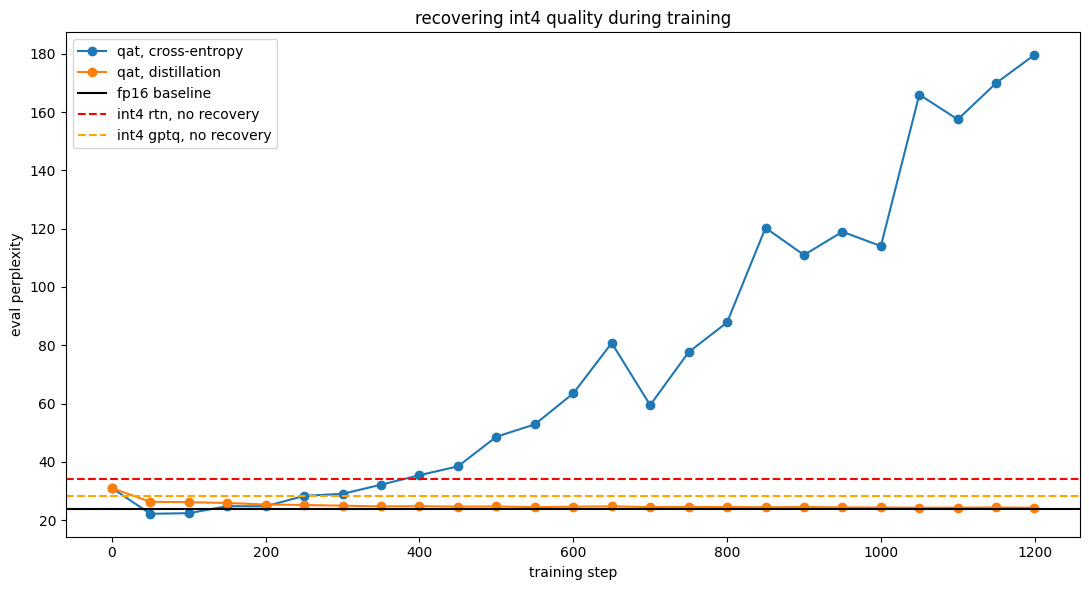

In [16]:
plt.figure(figsize=(11, 6))
ce_steps = [s for s, p in qat_results['ce']['eval_curve']]
ce_ppls = [p for s, p in qat_results['ce']['eval_curve']]
kd_steps = [s for s, p in qat_results['kd']['eval_curve']]
kd_ppls = [p for s, p in qat_results['kd']['eval_curve']]
plt.plot(ce_steps, ce_ppls, marker='o', label='qat, cross-entropy')
plt.plot(kd_steps, kd_ppls, marker='o', label='qat, distillation')
plt.axhline(baseline_ppl, color='black', linestyle='-', label='fp16 baseline')
int4_rtn_ppl = [r for r in ptq_records if r.technique=='int4_rtn'][0].quality.perplexity
int4_gptq_ppl = [r for r in ptq_records if r.technique=='int4_gptq'][0].quality.perplexity
plt.axhline(int4_rtn_ppl, color='red', linestyle='--', label='int4 rtn, no recovery')
plt.axhline(int4_gptq_ppl, color='orange', linestyle='--', label='int4 gptq, no recovery')
plt.xlabel('training step')
plt.ylabel('eval perplexity')
plt.title('recovering int4 quality during training')
plt.legend()
plt.tight_layout()
plt.show()

### plot 2: training loss curves

diagnostic, not the headline result - confirms both runs actually converged rather than stalling.

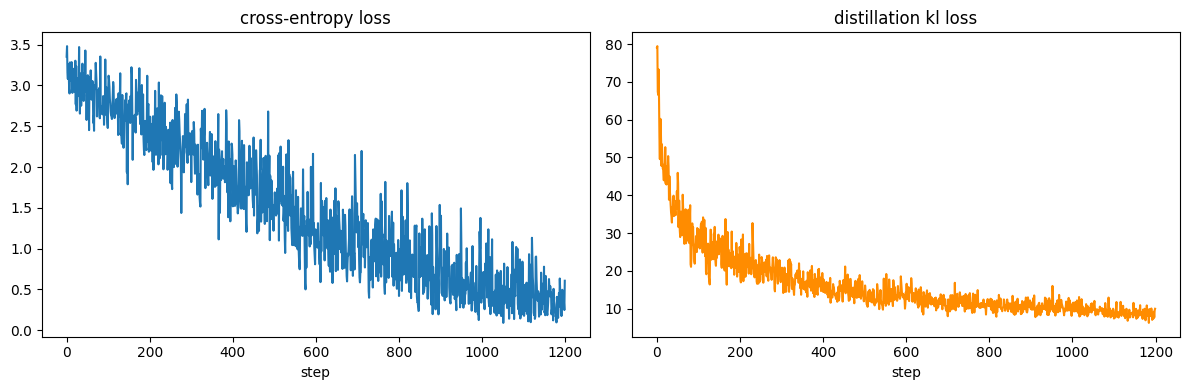

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(qat_results['ce']['loss_curve'])
axes[0].set_title('cross-entropy loss')
axes[0].set_xlabel('step')
axes[1].plot(qat_results['kd']['loss_curve'], color='darkorange')
axes[1].set_title('distillation kl loss')
axes[1].set_xlabel('step')
plt.tight_layout()
plt.show()

### plot 3: per-layer quantization error, ptq vs qat

mean squared error between each linear layer's original fp16 weight and its quantized version, one bar per layer, rtn against the recovered qat weight. shows where recovery actually helps rather than just an aggregate number.

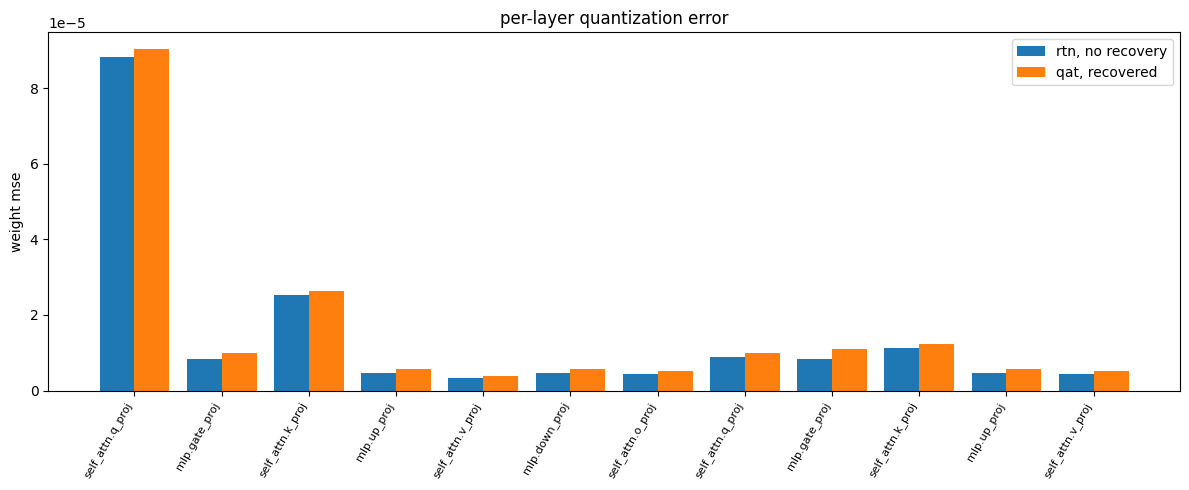

In [18]:
def per_layer_mse(original_model, quantized_state_dict_getter, layer_names):
  errors = []
  for name, module in original_model.named_modules():
    if isinstance(module, nn.Linear) and name in layer_names:
      orig_w = module.weight.data.float()
      quant_w = quantized_state_dict_getter(name)
      if quant_w is not None:
        errors.append((name, ((orig_w-quant_w.to(orig_w.device))**2).mean().item()))
  return errors


sample_layer_names = []
for name, module in base_model.named_modules():
  if isinstance(module, nn.Linear) and 'lm_head' not in name and 'embed_tokens' not in name:
    sample_layer_names.append(name)
sample_layer_names = sample_layer_names[::4][:12]

rtn_model_for_plot = copy.deepcopy(base_model)
quantize_model_weights_rtn(rtn_model_for_plot, bits=4, group_size=128)

def get_rtn_weight(name):
  for n, m in rtn_model_for_plot.named_modules():
    if n==name:
      return m.weight.data.float()
  return None

def get_qat_weight(name):
  for n, m in qat_results['ce']['model'].named_modules():
    if n==name and hasattr(m, 'effective_weight'):
      return m.effective_weight().detach()
  return None

rtn_errors = per_layer_mse(base_model, get_rtn_weight, sample_layer_names)
qat_errors = per_layer_mse(base_model, get_qat_weight, sample_layer_names)

del rtn_model_for_plot
gc.collect()

names = [n.split('.')[-2]+'.'+n.split('.')[-1] for n, e in rtn_errors]
rtn_vals = [e for n, e in rtn_errors]
qat_vals = [e for n, e in qat_errors]

x = np.arange(len(names))
plt.figure(figsize=(12, 5))
plt.bar(x-0.2, rtn_vals, width=0.4, label='rtn, no recovery')
plt.bar(x+0.2, qat_vals, width=0.4, label='qat, recovered')
plt.xticks(x, names, rotation=60, ha='right', fontsize=8)
plt.ylabel('weight mse')
plt.title('per-layer quantization error')
plt.legend()
plt.tight_layout()
plt.show()

### plot 4: weight distribution before and after qat

one representative layer, histogram of weight values before training and after. the classic qat signature is weights migrating away from the middle of each rounding bucket toward the edges, so rounding costs less.

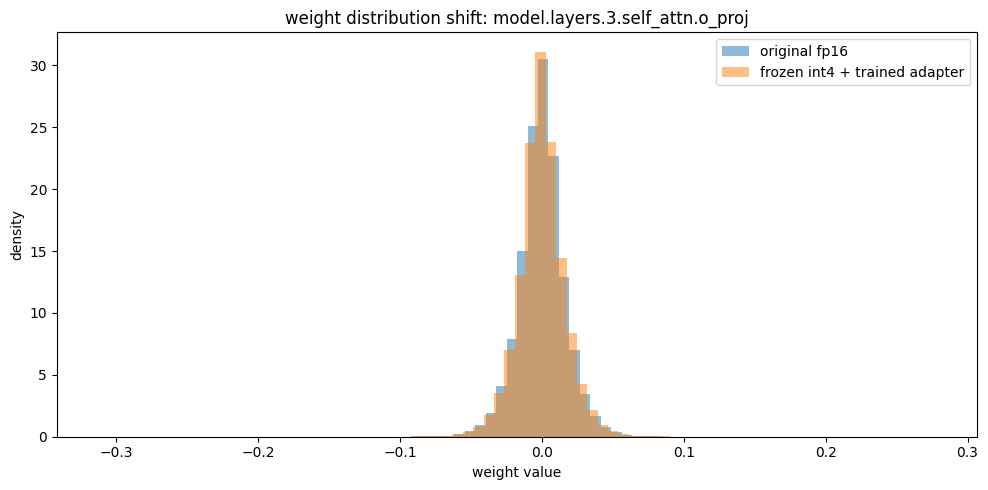

In [19]:
sample_name = sample_layer_names[len(sample_layer_names)//2]
orig_weight = None
for n, m in base_model.named_modules():
  if n==sample_name:
    orig_weight = m.weight.data.float().flatten().cpu().numpy()
qat_weight = None
for n, m in qat_results['ce']['model'].named_modules():
  if n==sample_name and hasattr(m, 'effective_weight'):
    qat_weight = m.effective_weight().flatten().detach().cpu().numpy()

plt.figure(figsize=(10, 5))
plt.hist(orig_weight, bins=80, alpha=0.5, label='original fp16', density=True)
plt.hist(qat_weight, bins=80, alpha=0.5, label='frozen int4 + trained adapter', density=True)
plt.xlabel('weight value')
plt.ylabel('density')
plt.title(f'weight distribution shift: {sample_name}')
plt.legend()
plt.tight_layout()
plt.show()

## adding recovered builds to the matrix

In [20]:
def evaluate_trained_model(model, tokenizer, device, technique, bits, group_size, eval_texts, eval_set, baseline_ppl, baseline_acc):
  model_copy = copy.deepcopy(model).half().to(device)
  model_copy.config.use_cache = True
  model_copy.gradient_checkpointing_disable()
  ppl = compute_perplexity(model_copy, tokenizer, eval_texts, device=device)
  acc = evaluate_multiple_choice(model_copy, tokenizer, eval_set, device=device)
  perf = benchmark_generation(model_copy, tokenizer, 'the weather today is', device=device, max_new_tokens=48)
  record = build_record(
    build_id=f'{technique}_{detect_hardware_tag(device)}', model_name=model_name, technique=technique,
    bits=bits, group_size=group_size, hardware_tag=detect_hardware_tag(device), workload_tag='general',
  )
  record.quality.perplexity = ppl
  record.quality.downstream_accuracy = acc
  record.quality.perplexity_delta_pct = 100.0*(ppl-baseline_ppl)/baseline_ppl
  record.quality.downstream_delta_pct = 100.0*(baseline_acc-acc)/baseline_acc if baseline_acc>0 else None
  record.perf.tokens_per_sec = perf['tokens_per_sec']
  record.perf.ttft_ms = perf['ttft_ms']
  record.perf.peak_memory_gb = perf['peak_memory_gb']
  record.perf.weight_memory_gb = model_weight_memory_gb(model_copy)
  del model_copy
  gc.collect()
  if device.startswith('cuda'):
    torch.cuda.empty_cache()
  return record


qat_ce_record = evaluate_trained_model(qat_results['ce']['model'], tokenizer, device_0, 'int4_qat_ce', 4, 128, eval_texts, eval_set, baseline_ppl, baseline_acc)
qat_kd_record = evaluate_trained_model(qat_results['kd']['model'], tokenizer, device_1, 'int4_qat_kd', 4, 128, eval_texts, eval_set, baseline_ppl, baseline_acc)

matrix.apply_quality_gate(qat_ce_record)
matrix.apply_quality_gate(qat_kd_record)
matrix.add(qat_ce_record)
matrix.add(qat_kd_record)

print(matrix.summary_table())

build_id                technique           hw          tok/s   mem_gb  ppl_delta%   gate
-----------------------------------------------------------------------------------------
fp16_t4                 fp16                t4           29.6     1.87           -   pass
int8_rtn_t4             int8_rtn            t4           19.8     1.88        0.52   pass
int4_rtn_t4             int4_rtn            t4           22.0     0.94       42.92   fail
int4_gptq_t4            int4_gptq           t4           29.9     1.88       17.78   fail
int4_qat_ce_t4          int4_qat_ce         t4           20.4     3.78      809.31   fail
int4_qat_kd_t4          int4_qat_kd         t4           19.7     3.77       10.73   fail


### plot 5: the full quality gate

every technique so far, perplexity delta against the fp16 baseline, with the 5% gate threshold marked. answers the question pillar 1 exists to answer: does recovery actually move a failing build to a passing one.

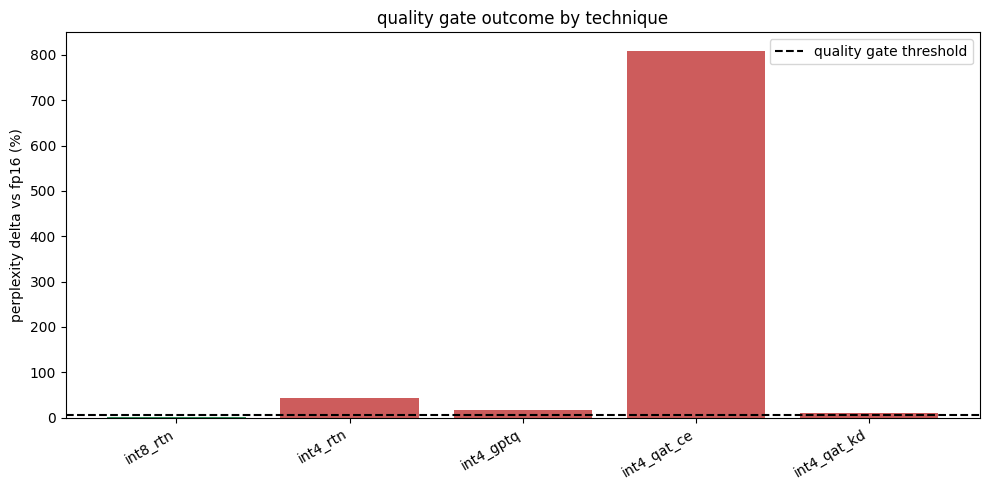

In [21]:
techniques = [r.technique for r in matrix.records if r.quality.perplexity_delta_pct is not None]
deltas = [r.quality.perplexity_delta_pct for r in matrix.records if r.quality.perplexity_delta_pct is not None]
colors = ['seagreen' if r.passed_quality_gate else 'indianred' for r in matrix.records if r.quality.perplexity_delta_pct is not None]

plt.figure(figsize=(10, 5))
plt.bar(techniques, deltas, color=colors)
plt.axhline(5.0, color='black', linestyle='--', label='quality gate threshold')
plt.ylabel('perplexity delta vs fp16 (%)')
plt.title('quality gate outcome by technique')
plt.xticks(rotation=30, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

## pillar 2: speculative decoding

a small draft model proposes several tokens at once, a larger target model checks all of them in a single forward pass. every proposed token that matches what the target would have picked on its own is kept for free; the first mismatch is thrown away and replaced with the target's real token, and drafting resumes from there.

under an exact-match acceptance rule this is provably lossless: the final output is identical to running the target model alone, token by token, the entire time. the open question, and the one the internship's own reading list points at directly, is what happens when that acceptance rule is relaxed to trade a little correctness for more speed.

In [22]:
target_model_name = 'Qwen/Qwen2.5-1.5B'
target_model = AutoModelForCausalLM.from_pretrained(target_model_name, torch_dtype=torch.float16).to(device_0)
target_model.eval()
print('target model loaded:', sum(p.numel() for p in target_model.parameters())/1e6, 'm params')

config.json:   0%|          | 0.00/684 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

target model loaded: 1543.714304 m params


In [23]:
@torch.no_grad()
def greedy_generate(model, input_ids, n_new_tokens):
  tokens = input_ids.clone()
  for _ in range(n_new_tokens):
    logits = model(tokens).logits
    next_token = logits[:, -1, :].argmax(dim=-1, keepdim=True)
    tokens = torch.cat([tokens, next_token], dim=1)
  return tokens


@torch.no_grad()
def speculative_generate(draft, target, input_ids, n_new_tokens, k, rank_tolerance):
  tokens = input_ids.clone()
  n_generated = 0
  n_proposed = 0
  n_accepted = 0
  while n_generated<n_new_tokens:
    draft_tokens = tokens.clone()
    proposed = []
    for _ in range(k):
      logits = draft(draft_tokens).logits
      next_token = logits[:, -1, :].argmax(dim=-1, keepdim=True)
      draft_tokens = torch.cat([draft_tokens, next_token], dim=1)
      proposed.append(next_token)
    target_logits = target(draft_tokens).logits
    base_len = tokens.shape[1]
    accepted_count = 0
    for i, prop_token in enumerate(proposed):
      pos = base_len-1+i
      target_dist = target_logits[:, pos, :]
      target_top1 = target_dist.argmax(dim=-1, keepdim=True)
      if rank_tolerance<=1:
        ok = (prop_token==target_top1).all().item()
      else:
        rank = (target_dist>target_dist.gather(1, prop_token)).sum(dim=-1)
        ok = (rank<rank_tolerance).all().item()
      n_proposed += 1
      if ok:
        accepted_count += 1
        n_accepted += 1
      else:
        break
    if accepted_count>0:
      tokens = torch.cat([tokens, torch.cat(proposed[:accepted_count], dim=1)], dim=1)
      n_generated += accepted_count
    if accepted_count<k and n_generated<n_new_tokens:
      pos = base_len-1+accepted_count
      correction = target_logits[:, pos, :].argmax(dim=-1, keepdim=True)
      tokens = torch.cat([tokens, correction], dim=1)
      n_generated += 1
  return tokens[:, :input_ids.shape[1]+n_new_tokens], n_proposed, n_accepted

### losslessness proof

exact acceptance (tolerance 1) must produce byte-identical output to plain greedy decoding on the target alone, across several different prompts. not a plot - a checkable pass or fail.

In [24]:
spec_prompts = [
  'the best way to reduce latency in a real-time voice agent is',
  'quantization aware training works by',
  'the history of computing spans several centuries, beginning with',
  'in machine learning, a common approach to model compression is',
  'the weather forecast for tomorrow shows',
]

all_match = True
for prompt in spec_prompts:
  input_ids = tokenizer(prompt, return_tensors='pt').input_ids.to(device_0)
  baseline = greedy_generate(target_model, input_ids, 24)
  spec, n_prop, n_acc = speculative_generate(base_model, target_model, input_ids, 24, k=4, rank_tolerance=1)
  match = torch.equal(baseline, spec)
  all_match = all_match and match
  print('prompt:', prompt[:40], '... exact match:', match)

print()
print('losslessness holds across all prompts:', all_match)

prompt: the best way to reduce latency in a real ... exact match: True
prompt: quantization aware training works by ... exact match: True
prompt: the history of computing spans several c ... exact match: True
prompt: in machine learning, a common approach t ... exact match: True
prompt: the weather forecast for tomorrow shows ... exact match: True

losslessness holds across all prompts: True


### the tradeoff frontier

relaxing the acceptance rule from exact top-1 matching to accepting anything within the target's top-k. speedup against target-only decoding on one axis, fraction of output tokens that differ from the true greedy baseline on the other.

In [25]:
tolerances = [1, 2, 3, 5, 10, 20]
frontier_speedup = []
frontier_divergence = []
frontier_acceptance = []

for tol in tolerances:
  total_baseline_time = 0.0
  total_spec_time = 0.0
  total_divergent = 0
  total_tokens = 0
  total_prop = 0
  total_acc = 0
  for prompt in spec_prompts:
    input_ids = tokenizer(prompt, return_tensors='pt').input_ids.to(device_0)
    start = time.perf_counter()
    baseline = greedy_generate(target_model, input_ids, 32)
    total_baseline_time += time.perf_counter()-start
    start = time.perf_counter()
    spec, n_prop, n_acc = speculative_generate(base_model, target_model, input_ids, 32, k=4, rank_tolerance=tol)
    total_spec_time += time.perf_counter()-start
    total_divergent += (spec!=baseline).float().sum().item()
    total_tokens += baseline.numel()
    total_prop += n_prop
    total_acc += n_acc
  frontier_speedup.append(total_baseline_time/total_spec_time)
  frontier_divergence.append(total_divergent/total_tokens)
  frontier_acceptance.append(total_acc/total_prop)
  print('tolerance', tol, 'speedup', round(frontier_speedup[-1], 2), 'divergence', round(frontier_divergence[-1], 3), 'acceptance', round(frontier_acceptance[-1], 3))

tolerance 1 speedup 0.53 divergence 0.0 acceptance 0.681
tolerance 2 speedup 0.64 divergence 0.602 acceptance 0.805
tolerance 3 speedup 0.71 divergence 0.607 acceptance 0.869
tolerance 5 speedup 0.81 divergence 0.67 acceptance 0.94
tolerance 10 speedup 0.84 divergence 0.684 acceptance 0.976
tolerance 20 speedup 0.87 divergence 0.709 acceptance 0.994


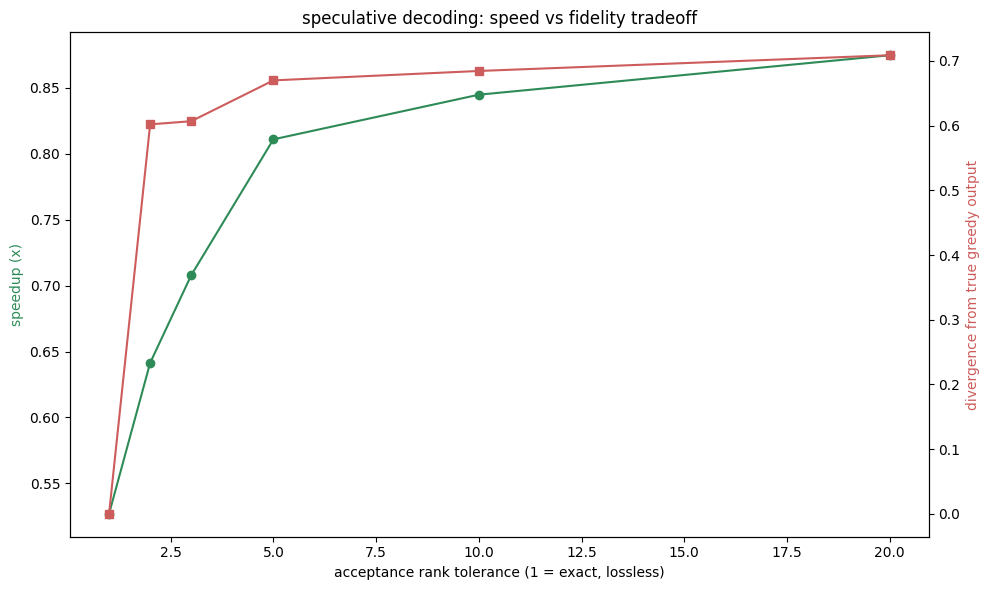

In [26]:
fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()
ax1.plot(tolerances, frontier_speedup, marker='o', color='seagreen', label='speedup vs target-only')
ax2.plot(tolerances, frontier_divergence, marker='s', color='indianred', label='fraction of tokens diverged')
ax1.set_xlabel('acceptance rank tolerance (1 = exact, lossless)')
ax1.set_ylabel('speedup (x)', color='seagreen')
ax2.set_ylabel('divergence from true greedy output', color='indianred')
ax1.set_title('speculative decoding: speed vs fidelity tradeoff')
fig.tight_layout()
plt.show()

### does the draft model's own quantization change acceptance

three drafts checked against the same fp16 target, all under the exact lossless criterion: the original fp16 draft, a plain int4 rtn draft, and the qat-recovered int4 draft from pillar 1. if quantization recovery matters beyond the quality gate itself, a better-recovered draft should get accepted by the target more often.

In [27]:
rtn_draft = copy.deepcopy(base_model)
quantize_model_weights_rtn(rtn_draft, bits=4, group_size=128)

qat_draft = qat_results['ce']['model'].half()

draft_variants = {
  'fp16 draft': base_model,
  'int4 rtn draft': rtn_draft,
  'int4 qat draft': qat_draft,
}

acceptance_by_precision = {}
for label, draft in draft_variants.items():
  total_prop = 0
  total_acc = 0
  for prompt in spec_prompts:
    input_ids = tokenizer(prompt, return_tensors='pt').input_ids.to(device_0)
    spec, n_prop, n_acc = speculative_generate(draft, target_model, input_ids, 32, k=4, rank_tolerance=1)
    total_prop += n_prop
    total_acc += n_acc
  acceptance_by_precision[label] = total_acc/total_prop
  print(label, 'acceptance rate', round(acceptance_by_precision[label], 3))

del rtn_draft
gc.collect()

fp16 draft acceptance rate 0.681
int4 rtn draft acceptance rate 0.636
int4 qat draft acceptance rate 0.409


507

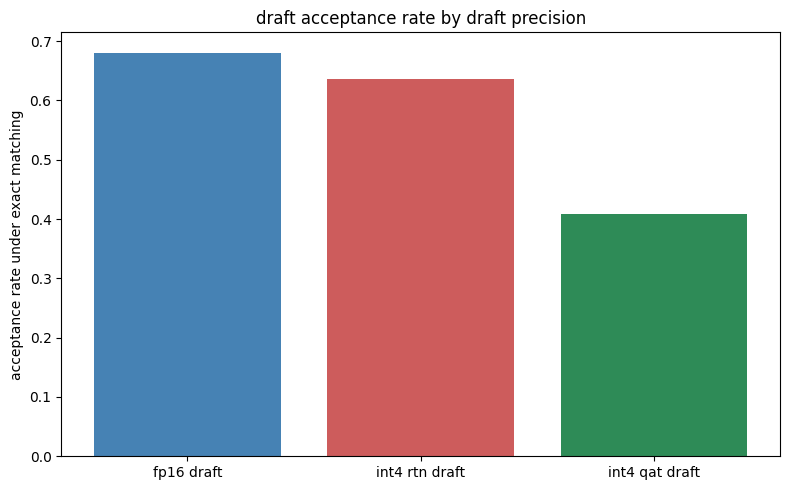

In [28]:
plt.figure(figsize=(8, 5))
plt.bar(list(acceptance_by_precision.keys()), list(acceptance_by_precision.values()), color=['steelblue', 'indianred', 'seagreen'])
plt.ylabel('acceptance rate under exact matching')
plt.title('draft acceptance rate by draft precision')
plt.tight_layout()
plt.show()